In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("datasets/data1.csv")

In [ ]:
df.head()

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647


In [ ]:
X = df.iloc[:, 0:3].values
y = df.iloc[:, -1].values

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
y_pred = model.predict(X_test)
residual = y_test - y_pred

In [ ]:
residual

array([ 32.30806809,   0.46904443, -31.32809124,  22.08116144,
       -19.48224904,  14.53811846, -13.06186752,  -6.4005597 ,
        39.20256545, -29.29044906,   4.75248151, -19.57569445,
        -3.0065195 , -10.3924627 , -21.25888025,  11.55754461,
         8.62447468, -18.07049676,  -4.94076456,  35.61424035,
        20.12399832,  12.27393405, -26.31860141, -45.95327491,
         3.37760864, -11.49543562,  10.9718074 ,   6.30338945,
       -12.76318311,   8.71883535, -14.22352902,  15.87149439,
         8.46501917,  20.24567261, -20.1977093 ,  14.87670373,
        -3.57968224,  24.32042365, -18.93235423,   4.8939494 ,
        22.49334603, -37.72924312, -28.40177141, -41.04190332,
        11.18585659,   2.09365624, -12.96308959,  18.61567073,
       -22.47871086,  12.42202957,  -2.29240143,   7.67369719,
        20.01054442,   7.09808748,   0.77941307,  33.59206216,
       -23.14001768,  20.90778006,  -2.74463247,  10.58652756])

### 1. Linear Relationship

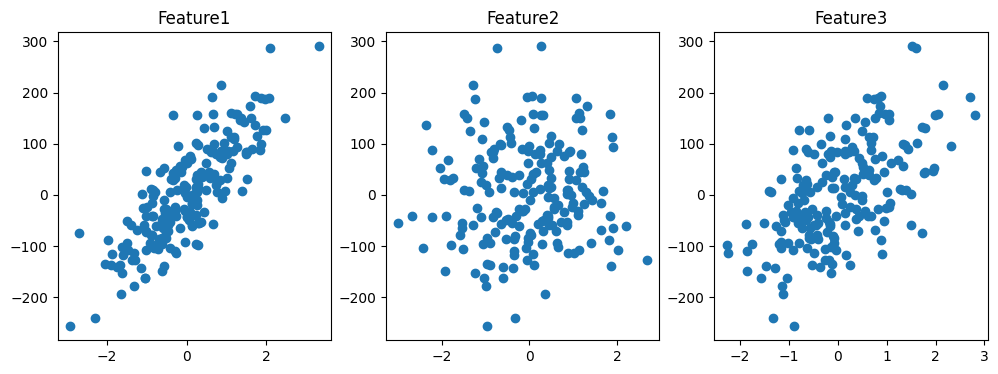

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(12, 4))

ax1.scatter(df['feature1'], df['target'])
ax1.set_title("Feature1")

ax2.scatter(df['feature2'], df['target'])
ax2.set_title("Feature2")

ax3.scatter(df['feature3'], df['target'])
ax3.set_title("Feature3")

plt.show()

### 2. Multicollinearity

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = []

for i in range (X_train.shape[1]):
    vif.append(variance_inflation_factor(X_train, i))
print(vif)

[np.float64(1.0103257033229724), np.float64(1.009871080069871), np.float64(1.0139501973126548)]


In [ ]:
pd.DataFrame({'vif': vif}, index=df.columns[0:3]).T

,feature1,feature2,feature3
vif,1.010326,1.009871,1.01395


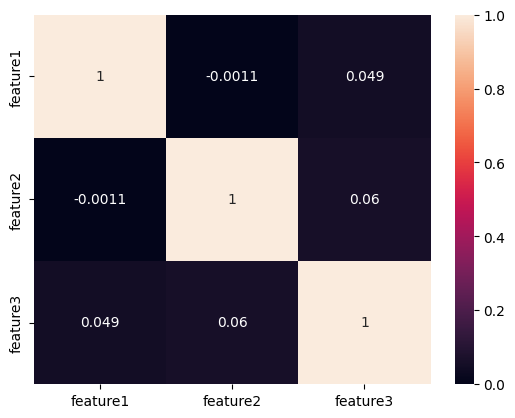

In [ ]:
## Another technique
sns.heatmap(df.iloc[:, 0:3].corr(), annot=True);

### Normality of Residual

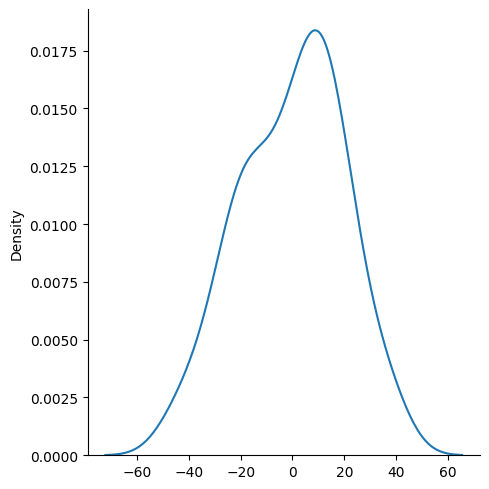

In [ ]:
sns.displot(residual, kind='kde');

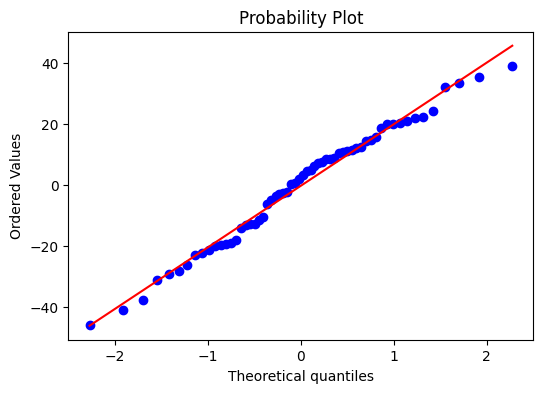

In [ ]:
import scipy as sp

fig, ax = plt.subplots(figsize = (6,4))
sp.stats.probplot(residual, plot=ax, fit=True)

plt.show()

### Homoscedasticity

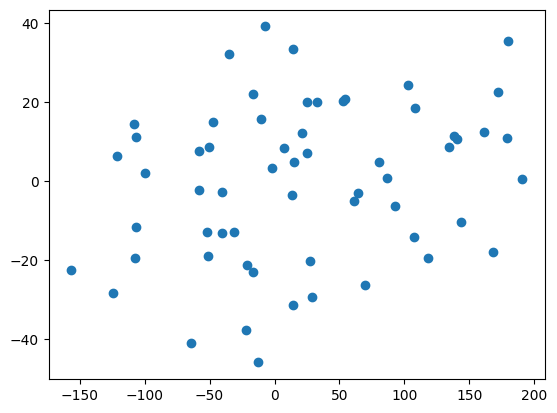

In [ ]:
plt.scatter(y_pred, residual);

### Autocorrelation of Residuals

In [ ]:
plt.plot(residual);